# Step 1 — Configuration, Imports, and Helper Functions

In this step, we:
- Set up key **configuration parameters** such as dataset URL, training seeds, epochs, and ablation ranges.  
- Import core libraries for **data processing, feature selection, model training, and evaluation**.  
- Define helper functions including:
  - **Focal loss** (optional, for imbalanced data).  
  - **Model builder** (Multi-Layer Perceptron with dropout, batch norm).  
  - **Data loading, splitting, and scaling** (ensures no leakage).  
  - **Feature selection** (SelectKBest + RandomForest intersection).  
  - **Class weight computation** (handles imbalance).  
  - **Training & evaluation utilities** (ensemble, threshold tuning).

In [1]:
# ========================== CONFIG ==========================
DATA_URL = "https://raw.githubusercontent.com/Viishnu07/DLI_GroupAE_URLPhishing/main/dataset/mendeley_dataset_full.csv"

# Core toggles
USE_CLASS_WEIGHTS = True       # if labels are ~50/50, try False too
USE_FOCAL_LOSS = False         # may boost recall; can lower precision
USE_COSINE_DECAY = False       # smoother LR schedule

# Seeds & training limits
SEEDS_FAST = [7, 17, 27]  # quick ablation
SEEDS_ALL  = [7, 11, 17, 23, 29, 31, 37, 41, 43, 47, 53]  # full list
NUM_SEEDS  = 5            # set 5 for fast final, 11 for “quality” final

EPOCHS_FAST, PATIENCE_FAST = 40, 6       # ablation
EPOCHS_QUALITY, PATIENCE_QUALITY = 100, 10  # final ensemble

# Feature ablation range (train-only selection)
K_MIN, K_MAX = 18, 30

# ====================== IMPORTS & UTILS =====================
import time, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

print("TF devices:", tf.config.list_physical_devices())

# ---------- Focal loss (binary) ----------
def focal_loss(gamma=1.5, alpha=0.25):
    def _fl(y_true, y_pred):
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        pt = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        w  = tf.where(K.equal(y_true, 1), alpha, 1 - alpha)
        return -K.mean(w * K.pow(1 - pt, gamma) * K.log(pt))
    return _fl

# ---------- Model builder ----------
def build_model(input_dim, wide=False, lr=1e-3, drop_main=0.2, drop_last=0.15,
                use_cosine=False, use_focal=False):
    model = Sequential([Input(shape=(input_dim,))])
    if wide:
        units = [256, 128, 64]
        drops = [drop_main, drop_main, drop_last]
    else:
        units = [128, 64]
        drops = [drop_main, drop_main]
    for u, d in zip(units, drops):
        model.add(Dense(u, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(d))
    model.add(Dense(1, activation='sigmoid'))

    if use_cosine:
        schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=lr, decay_steps=EPOCHS_QUALITY * 100
        )
        opt = tf.keras.optimizers.Adam(learning_rate=schedule)
    else:
        opt = tf.keras.optimizers.Adam(learning_rate=lr)

    loss_fn = focal_loss() if use_focal else 'binary_crossentropy'
    model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])
    return model

# ---------- Leak-safe load → split → scale ----------
def load_and_split(test_size=0.2, val_size=0.2, rs=42):
    df = pd.read_csv(DATA_URL)
    df.drop_duplicates(inplace=True)
    df.replace(-1, np.nan, inplace=True)
    df.fillna(df.mean(numeric_only=True), inplace=True)

    X_full = df.drop(columns=['phishing'])
    y_full = df['phishing'].to_numpy()

    X_dev_df, X_test_df, y_dev, y_test = train_test_split(
        X_full, y_full, stratify=y_full, test_size=test_size, random_state=rs
    )
    X_train_df, X_val_df, y_train, y_val = train_test_split(
        X_dev_df, y_dev, stratify=y_dev, test_size=val_size, random_state=rs
    )

    scaler = MinMaxScaler().fit(X_train_df)  # fit on TRAIN only
    X_train_s = scaler.transform(X_train_df)
    X_val_s   = scaler.transform(X_val_df)
    X_test_s  = scaler.transform(X_test_df)

    return (X_train_df, X_val_df, X_test_df,
            X_train_s,  X_val_s,  X_test_s,
            y_train,     y_val,    y_test)

# ---------- Train-only feature selection (ANOVA ∩ RF) ----------
def select_features_train_only(X_train_df, X_train_s, y_train, X_val_s, X_test_s, k_feats=26, rs=42):
    k_feats = min(k_feats, X_train_s.shape[1])
    skb = SelectKBest(score_func=f_classif, k=k_feats).fit(X_train_s, y_train)
    top_skb = set(X_train_df.columns[skb.get_support()])

    rf = RandomForestClassifier(n_estimators=200, random_state=rs).fit(X_train_s, y_train)
    rf_imp = pd.Series(rf.feature_importances_, index=X_train_df.columns).sort_values(ascending=False)
    top_rf = set(rf_imp.index[:k_feats])

    feats = list(top_skb.intersection(top_rf))
    if len(feats) < max(18, k_feats // 2):  # fallback if intersection too small
        feats = list(top_skb)

    def sub(X_s):  # keep column alignment by DataFrame, then to numpy
        return pd.DataFrame(X_s, columns=X_train_df.columns)[feats].to_numpy()

    return sub(X_train_s), sub(X_val_s), sub(X_test_s), feats

# ---------- Class weights ----------
def get_class_weights(y):
    if not USE_CLASS_WEIGHTS:
        return None
    classes = np.unique(y)
    w = compute_class_weight(class_weight='balanced', classes=classes, y=y)
    return {int(c): float(wi) for c, wi in zip(classes, w)}

# ---------- Train one seed ----------
def train_one_seed(X_train, y_train, X_val, y_val, seed,
                   wide=False, epochs=60, patience=8, lr=1e-3):
    np.random.seed(seed); tf.random.set_seed(seed)
    model = build_model(X_train.shape[1], wide=wide, lr=lr,
                        use_cosine=USE_COSINE_DECAY, use_focal=USE_FOCAL_LOSS)
    es = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    cw = get_class_weights(y_train)
    model.fit(X_train, y_train,
              epochs=epochs, batch_size=128,
              validation_data=(X_val, y_val),
              callbacks=[es],
              verbose=1,
              class_weight=cw)
    return model

# ---------- Ensemble predict ----------
def predict_ensemble(models, X_val, X_test):
    val_probs = [m.predict(X_val, verbose=0).ravel() for m in models]
    test_probs = [m.predict(X_test, verbose=0).ravel() for m in models]
    val_ens = np.mean(np.column_stack(val_probs), axis=1)
    test_ens = np.mean(np.column_stack(test_probs), axis=1)
    return val_ens, test_ens

# ---------- Threshold tune (VAL) → Final TEST eval (returns arrays) ----------
def tune_and_eval(val_probs, y_val, test_probs, y_test):
    import numpy as np, time
    from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                 f1_score, roc_auc_score, confusion_matrix)

    ths = np.linspace(0.35, 0.65, 301)
    best_thr, best_f1 = 0.5, -1.0
    for t in ths:
        f1v = f1_score(y_val, (val_probs > t).astype(int))
        if f1v > best_f1:
            best_f1, best_thr = f1v, t

    start = time.time()
    y_pred = (test_probs > best_thr).astype(int)
    infer = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, test_probs)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tpr, fpr = tp/(tp+fn), fp/(fp+tn)
    score_time = 1.0/(1.0+infer)
    aps = 0.3*acc + 0.25*(1 - fpr) + 0.25*tpr + 0.2*score_time

    metrics = {
        "thr": float(best_thr), "acc": float(acc), "prec": float(prec), "rec": float(rec),
        "f1": float(f1), "auc": float(auc), "fpr": float(fpr),
        "infer_ms": float((infer/len(y_test))*1000), "aps": float(aps)
    }
    return metrics, y_test, y_pred, test_probs


TF devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Step 2 — Load, Split & Feature Ablation

Here we:
- Load the dataset, drop duplicates, and fill missing values.  
- Split into **train, validation, test** sets (with stratification).  
- Perform **feature ablation** for `k = 18..30`, training quick 3-seed ensembles on validation data.  
- Select the best `k` (number of features) based on **highest F1 score**.


In [2]:
# ===================== 1) LOAD & SPLIT ======================
X_train_df, X_val_df, X_test_df, X_train_s, X_val_s, X_test_s, y_train, y_val, y_test = load_and_split()

# ========= 2) FEATURE ABLATION (k = 18..30), FAST ===========
ablation = []
for k in range(K_MIN, K_MAX + 1):
    Xtr_k, Xv_k, Xte_k, feats = select_features_train_only(
        X_train_df, X_train_s, y_train, X_val_s, X_test_s, k_feats=k
    )
    print(f"\n[Ablation] k={k} | features used={len(feats)}")
    # quick 3-seed ensemble on VAL to score this k
    models_tmp = []
    for s in SEEDS_FAST:
        m = train_one_seed(Xtr_k, y_train, Xv_k, y_val, seed=s,
                           wide=False, epochs=EPOCHS_FAST, patience=PATIENCE_FAST, lr=1e-3)
        models_tmp.append(m)
    val_probs_tmp, _ = predict_ensemble(models_tmp, Xv_k, Xte_k)  # only need VAL to choose k

    # tune threshold on VAL for this k
    ths = np.linspace(0.35, 0.65, 301)
    best_f1, best_thr = -1, 0.5
    for t in ths:
        f1v = f1_score(y_val, (val_probs_tmp > t).astype(int))
        if f1v > best_f1:
            best_f1, best_thr = f1v, t
    ablation.append((k, best_f1, best_thr, len(feats)))
    print(f" -> VAL F1={best_f1:.4f} at thr={best_thr:.3f}")

ablation.sort(key=lambda x: x[1], reverse=True)
best_k, best_valF1, best_thr_guess, feat_count = ablation[0]
print("\n[Ablation Result] Best k:", best_k, "| VAL F1=", round(best_valF1, 4), "| features:", feat_count)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [22 23 24 25 26 27 28 29 30 31 32 33 34 35 44 54 61 62 72 73 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



[Ablation] k=18 | features used=18
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8387 - loss: 0.3445 - val_accuracy: 0.8931 - val_loss: 0.3259
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9092 - loss: 0.2118 - val_accuracy: 0.9192 - val_loss: 0.1825
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9142 - loss: 0.1997 - val_accuracy: 0.9199 - val_loss: 0.1819
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9142 - loss: 0.1992 - val_accuracy: 0.9207 - val_loss: 0.1808
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9161 - loss: 0.1938 - val_accuracy: 0.9245 - val_loss: 0.1736
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9171 - loss: 0.1922 - val_accuracy: 0.9260 - val_loss: 0.1708
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9182 - loss: 0.1876 - val_accuracy: 0.9321 - val_loss: 0.1647
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.91

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [22 23 24 25 26 27 28 29 30 31 32 33 34 35 44 54 61 62 72 73 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



[Ablation] k=19 | features used=19
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8508 - loss: 0.3368 - val_accuracy: 0.9103 - val_loss: 0.3009
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9073 - loss: 0.2148 - val_accuracy: 0.9187 - val_loss: 0.1880
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9132 - loss: 0.1994 - val_accuracy: 0.9270 - val_loss: 0.1693
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9136 - loss: 0.1955 - val_accuracy: 0.9297 - val_loss: 0.1675
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9184 - loss: 0.1898 - val_accuracy: 0.9290 - val_loss: 0.1684
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9175 - loss: 0.1896 - val_accuracy: 0.9318 - val_loss: 0.1633
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9199 - loss: 0.1848 - val_accuracy: 0.9326 - val_loss: 0.1619
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.92

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [22 23 24 25 26 27 28 29 30 31 32 33 34 35 44 54 61 62 72 73 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


...


[Ablation] k=28 | features used=28
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8440 - loss: 0.3497 - val_accuracy: 0.8988 - val_loss: 0.3092
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9116 - loss: 0.2060 - val_accuracy: 0.9200 - val_loss: 0.1797
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9222 - loss: 0.1872 - val_accuracy: 0.9322 - val_loss: 0.1548
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9273 - loss: 0.1775 - val_accuracy: 0.9416 - val_loss: 0.1460
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9322 - loss: 0.1682 - val_accuracy: 0.9349 - val_loss: 0.1528
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1643 - val_accuracy: 0.9422 - val_loss: 0.1428
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9335 - loss: 0.1640 - val_accuracy: 0.9454 - val_loss: 0.1400
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [22 23 24 25 26 27 28 29 30 31 32 33 34 35 44 54 61 62 72 73 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



[Ablation] k=29 | features used=29
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8646 - loss: 0.3029 - val_accuracy: 0.9266 - val_loss: 0.2576
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9159 - loss: 0.1977 - val_accuracy: 0.9339 - val_loss: 0.1597
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9253 - loss: 0.1813 - val_accuracy: 0.9367 - val_loss: 0.1507
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9270 - loss: 0.1762 - val_accuracy: 0.9342 - val_loss: 0.1558
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9337 - loss: 0.1660 - val_accuracy: 0.9374 - val_loss: 0.1482
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9346 - loss: 0.1646 - val_accuracy: 0.9394 - val_loss: 0.1505
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9362 - loss: 0.1617 - val_accuracy: 0.9422 - val_loss: 0.1444
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.93

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [22 23 24 25 26 27 28 29 30 31 32 33 34 35 44 54 61 62 72 73 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



[Ablation] k=30 | features used=30
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8305 - loss: 0.3620 - val_accuracy: 0.9005 - val_loss: 0.2875
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9106 - loss: 0.2062 - val_accuracy: 0.9307 - val_loss: 0.1598
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9196 - loss: 0.1892 - val_accuracy: 0.9293 - val_loss: 0.1629
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9246 - loss: 0.1788 - val_accuracy: 0.9323 - val_loss: 0.1594
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9298 - loss: 0.1742 - val_accuracy: 0.9377 - val_loss: 0.1484
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9318 - loss: 0.1688 - val_accuracy: 0.9425 - val_loss: 0.1427
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9347 - loss: 0.1637 - val_accuracy: 0.9430 - val_loss: 0.1432
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.93

# Step 3 — Train Final Ensemble

With the best number of features (`k`) chosen:
- Train a **wide MLP ensemble** using multiple random seeds.  
- Use **early stopping** for efficiency and stability.  
- Tune the **decision threshold** on validation, then freeze it and evaluate on test data.  
- Report performance metrics: Accuracy, Precision, Recall, F1, AUC, FPR, inference speed, and APS.


In [3]:
# ======== 3) FINAL ENSEMBLE (NUM_SEEDS seeds), TEST ========
# Rebuild data with best k
Xtr_k, Xv_k, Xte_k, feats_final = select_features_train_only(
    X_train_df, X_train_s, y_train, X_val_s, X_test_s, k_feats=best_k
)
print(f"\n[Final] Training ensemble with k={best_k} | features={len(feats_final)} | seeds={NUM_SEEDS}")

models = []
for i, s in enumerate(SEEDS_ALL[:NUM_SEEDS], 1):
    print(f"\n[Final] Seed {s} ({i}/{NUM_SEEDS})")
    m = train_one_seed(Xtr_k, y_train, Xv_k, y_val, seed=s,
                       wide=True, epochs=EPOCHS_QUALITY, patience=PATIENCE_QUALITY, lr=1e-3)
    models.append(m)

# Ensemble predictions & evaluate (threshold tuned on VAL, then frozen on TEST)
val_probs, test_probs = predict_ensemble(models, Xv_k, Xte_k)
result, y_test_final, y_pred_final, test_prob_ens = tune_and_eval(val_probs, y_val, test_probs, y_test)

print("\n================ FINAL ENSEMBLE — TEST ================")
for k, v in result.items():
    print(f"{k}: {v:.6f}" if isinstance(v, float) else f"{k}: {v}")

print("\nTop features used (k=%d):" % best_k, feats_final)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [22 23 24 25 26 27 28 29 30 31 32 33 34 35 44 54 61 62 72 73 90] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



[Final] Training ensemble with k=30 | features=30 | seeds=5

[Final] Seed 7 (1/5)
Epoch 1/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8453 - loss: 0.3392 - val_accuracy: 0.9245 - val_loss: 0.2485
Epoch 2/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9149 - loss: 0.2020 - val_accuracy: 0.9354 - val_loss: 0.1585
Epoch 3/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9242 - loss: 0.1836 - val_accuracy: 0.9402 - val_loss: 0.1482
Epoch 4/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9309 - loss: 0.1719 - val_accuracy: 0.9439 - val_loss: 0.1436
Epoch 5/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9327 - loss: 0.1690 - val_accuracy: 0.9363 - val_loss: 0.1575
Epoch 6/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9353 - loss: 0.1612 - val_accuracy: 0.9422 - val_loss: 0.1440
Epoch 7/100
437/437 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9381 - loss: 0.1561 - val_accuracy: 0.9440 - val_loss: 0.1429
Epoch 8/100


# Step 4 — Evaluation Plots

We visualize the final ensemble’s performance on the **test set**:
- Confusion Matrix (class distribution of predictions).  
- ROC Curve (trade-off between TPR and FPR, with AUC score).  
- Precision–Recall Curve (performance under class imbalance).  
- Save the plots as `.png` files for reports/presentations.

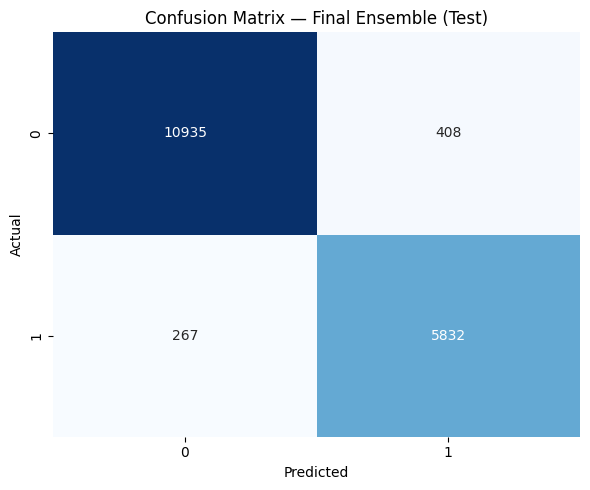

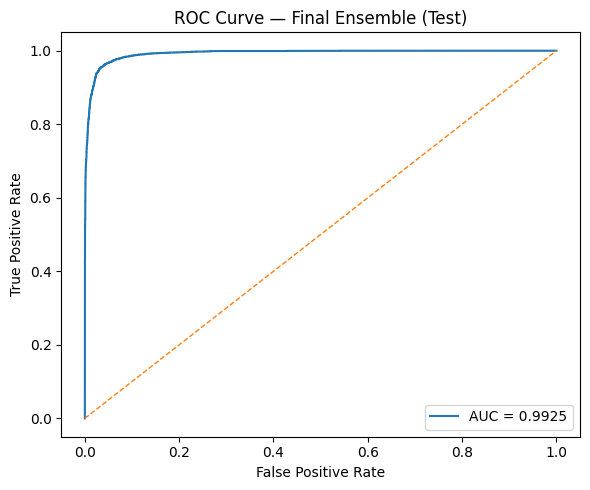

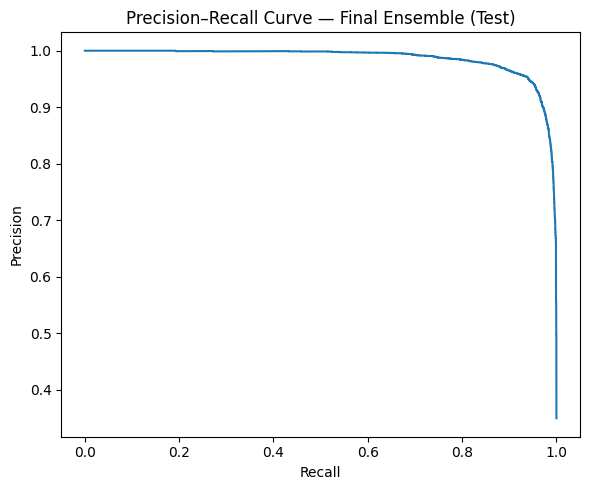

Saved: confusion_matrix_final.png, roc_curve_final.png, pr_curve_final.png


In [4]:
# ===================== 4) PLOTS =====================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

# Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix — Final Ensemble (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve
fpr_curve, tpr_curve, _ = roc_curve(y_test_final, test_prob_ens)
roc_auc = auc(fpr_curve, tpr_curve)
plt.figure(figsize=(6,5))
plt.plot(fpr_curve, tpr_curve, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Ensemble (Test)")
plt.legend()
plt.tight_layout()
plt.show()

# Precision–Recall Curve
precision, recall, _ = precision_recall_curve(y_test_final, test_prob_ens)
plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Final Ensemble (Test)")
plt.tight_layout()
plt.show()

# Save PNGs for slides (optional)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix — Final Ensemble (Test)")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout()
plt.savefig("confusion_matrix_final.png", dpi=300); plt.close()

plt.figure(figsize=(6,5))
plt.plot(fpr_curve, tpr_curve, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Ensemble (Test)")
plt.legend(); plt.tight_layout()
plt.savefig("roc_curve_final.png", dpi=300); plt.close()

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Final Ensemble (Test)")
plt.tight_layout()
plt.savefig("pr_curve_final.png", dpi=300); plt.close()

print("Saved: confusion_matrix_final.png, roc_curve_final.png, pr_curve_final.png")


# Step 5 — Real-time URL Inference + Gradio GUI

We now:
- Build an **inference pipeline** that converts a raw URL into the selected feature set.  
- Scale features using the training scaler.  
- Run predictions using the ensemble and decision threshold.  
- Add a **domain allowlist** (Google, Microsoft, etc.) to avoid false positives.  
- Deploy a **Gradio web interface** so users can test URLs interactively.

In [9]:
# ================= URL Inference + GUI (in-session) =================
# Requires: models, feats_final, result["thr"], X_train_df (from Steps 1–4)

!pip -q install gradio tldextract

import re
import numpy as np
import pandas as pd
from urllib.parse import urlparse
import tldextract
from sklearn.preprocessing import MinMaxScaler
import gradio as gr

# ---------- Inference scaler (fit on TRAIN for final features) ----------
scaler_infer = MinMaxScaler().fit(X_train_df[feats_final])
train_means = X_train_df[feats_final].mean(numeric_only=True)

# ---------- URL → feature helpers ----------
SHORTENERS = {
    "bit.ly","goo.gl","t.co","ow.ly","tinyurl.com","buff.ly","is.gd","rebrand.ly",
    "cutt.ly","t.ly","shorte.st","shorturl.at","v.gd","rb.gy","bit.do"
}
IPV4_RE = re.compile(r"^\d{1,3}(\.\d{1,3}){3}$")
VOWELS = set("aeiou")

def _safe_netloc(parsed):
    host = parsed.netloc.split("@")[-1]
    return host.split(":")[0]

def _is_ip(host):
    if not host: return 0
    if IPV4_RE.match(host):
        parts = host.split(".")
        return int(all(0 <= int(p) <= 255 for p in parts))
    return 0

def _registered_domain(url):
    ext = tldextract.extract(url)
    if ext.suffix:
        return f"{ext.domain}.{ext.suffix}"
    return ext.domain or ""

def _email_in_string(s):
    return int(bool(re.search(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}", s)))

def _is_shortener(host):
    return int(host.lower() in SHORTENERS)

def _count(s, ch):
    return s.count(ch)

def _path_and_filename(parsed):
    path = parsed.path or ""
    segs = [seg for seg in path.split("/") if seg]
    fname = segs[-1] if segs else ""
    return path, fname

def build_feature_row(url: str) -> pd.DataFrame:
    url = url.strip()
    if not re.match(r"^https?://", url, flags=re.I):
        url = "http://" + url
    parsed = urlparse(url)
    host = _safe_netloc(parsed)
    regdom = _registered_domain(url)
    path, filename = _path_and_filename(parsed)

    feats_local = {
        "length_url":              len(url),
        "qty_slash_url":           _count(url, "/"),
        "qty_hyphen_url":          _count(url, "-"),
        "qty_underline_url":       _count(url, "_"),
        "qty_questionmark_url":    _count(url, "?"),
        "qty_equal_url":           _count(url, "="),
        "qty_at_url":              _count(url, "@"),
        "qty_and_url":             _count(url, "&"),
        "qty_tilde_url":           _count(url, "~"),
        "qty_dot_url":             _count(url, "."),
        "qty_percent_url":         _count(url, "%"),
        "qty_dollar_url":          _count(url, "$"),
        "qty_plus_url":            _count(url, "+"),
        "qty_exclamation_url":     _count(url, "!"),
        "email_in_url":            _email_in_string(url),
        "url_shortened":           _is_shortener(host),
        "qty_dot_domain":          regdom.count("."),
        "qty_hyphen_domain":       regdom.count("-"),
        "qty_vowels_domain":       sum(1 for c in regdom.lower() if c in VOWELS),
        "domain_in_ip":            _is_ip(host),
        "directory_length":        len(path.strip("/")),
        "qty_slash_directory":     path.count("/"),
        "qty_dot_directory":       path.count("."),
        "qty_hyphen_directory":    path.count("-"),
        "qty_dot_file":            filename.count("."),
        "qty_redirects":           0,
    }

    # Some features might be "network-like" that we don't compute live here; fill with train means
    unknown_like = {
        "qty_mx_servers","qty_nameservers","qty_ip_resolved","asn_ip",
        "tls_ssl_certificate","time_domain_activation","time_domain_expiration",
        "url_google_index","domain_spf","qty_tld_url"
    }

    row = {}
    for f in feats_final:
        if f in feats_local:
            row[f] = feats_local[f]
        elif f in unknown_like:
            row[f] = float(train_means.get(f, 0.0))
        else:
            row[f] = float(train_means.get(f, 0.0))

    return pd.DataFrame([row], columns=feats_final)

# ---------- Tuned threshold from validation ----------
best_thr = float(result["thr"])

# ---------- SAFE allowlist of exact registered domains (override model) ----------
SAFE_ALLOWLIST = {
    "google.com", "microsoft.com", "apple.com", "amazon.com",
    "wikipedia.org", "linkedin.com", "bbc.com", "cnn.com",
    "reddit.com", "nytimes.com", "github.com", "paypal.com"
}

def predict_url(url: str, custom_thr=None):
    """
    Returns: (label_str, prob_float, registered_domain)
    - label_str: "Phishing (...)" or "Legit (...)" or "Legit (whitelisted: ...)"
    - prob_float: ensemble average probability of phishing
    - registered_domain: extracted registered domain for transparency
    """
    if not isinstance(url, str) or not url.strip():
        return "Enter a URL.", 0.0, ""
    try:
        # 1) Allowlist check on registered domain (robust against subdomain tricks)
        regdom = _registered_domain(url.strip()).lower()
        thr = float(custom_thr) if (custom_thr is not None and str(custom_thr).strip() != "") else best_thr
        if regdom in SAFE_ALLOWLIST:
            return f"Legit (whitelisted: {regdom})", 0.0, regdom

        # 2) Model inference
        row = build_feature_row(url)
        row_scaled = scaler_infer.transform(row)
        probs = [float(m.predict(row_scaled, verbose=0)[0][0]) for m in models]
        p_avg = float(np.mean(probs))
        label = "Phishing" if p_avg > thr else "Legit"
        return f"{label} (p={p_avg:.4f}, thr={thr:.3f})", p_avg, regdom
    except Exception as e:
        return f"Error: {e}", 0.0, ""

# ---------- Quick CLI sanity checks ----------
for u in [
    "https://www.google.com/",
    "http://paypal.com-security-alert-login.co/verify",
    "https://tinyurl.com/reset?login=update",
    "http://192.168.0.13/admin/login.php",
    "https://www.wikipedia.org/",
    "https://github.com/"
]:
    lbl, p, rd = predict_url(u)
    print(f"{u} -> {lbl} | regdom={rd}")

# ---------- Gradio mini GUI ----------
with gr.Blocks(title="Phishing URL Detector (MLP Ensemble)") as demo:
    gr.Markdown("### Phishing URL Detector\nEnter a URL to classify as **Phishing** or **Legit**.\n"
                "- Uses an ensemble of MLPs trained earlier\n"
                "- Applies a **registered-domain allowlist** for known-safe sites\n"
                "- You can raise the **threshold** to reduce false positives")
    url_in = gr.Textbox(label="URL", placeholder="e.g., https://example.com/login")
    thr_in = gr.Slider(label="Decision Threshold (higher = fewer false positives)",
                       minimum=0.01, maximum=0.99, step=0.01, value=float(best_thr))
    btn = gr.Button("Predict")
    out_label = gr.Textbox(label="Prediction")
    out_prob = gr.Number(label="Phishing probability (ensemble avg)")
    out_regdom = gr.Textbox(label="Registered domain")

    btn.click(fn=lambda u, t: predict_url(u, t),
              inputs=[url_in, thr_in],
              outputs=[out_label, out_prob, out_regdom])

# For Colab public link, set share=True
demo.launch(share=False)


https://www.google.com/ -> Legit (whitelisted: google.com) | regdom=google.com
http://paypal.com-security-alert-login.co/verify -> Phishing (p=0.9982, thr=0.507) | regdom=com-security-alert-login.co
https://tinyurl.com/reset?login=update -> Phishing (p=0.9999, thr=0.507) | regdom=tinyurl.com
http://192.168.0.13/admin/login.php -> Phishing (p=0.9967, thr=0.507) | regdom=192.168.0.13
https://www.wikipedia.org/ -> Legit (whitelisted: wikipedia.org) | regdom=wikipedia.org
https://github.com/ -> Legit (whitelisted: github.com) | regdom=github.com
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

# Step 6 — Save Artifacts

To avoid retraining every session:
- Save each trained MLP model (`.h5`).  
- Save the fitted scaler (`.pkl`).  
- Save the final selected feature list, tuned threshold, and training means (`.json`).  
These files will be reloaded later for inference.

In [10]:
# === SAVE ARTIFACTS ===
!pip -q install joblib
import os, json, joblib
os.makedirs("artifacts", exist_ok=True)

# 1) save each model in the ensemble
for i, m in enumerate(models):
    seed = SEEDS_ALL[:NUM_SEEDS][i]
    path = f"artifacts/phish_mlp_seed{seed}.h5"
    m.save(path)
    print("Saved model:", path)

# 2) save the inference scaler (fitted on X_train_df[feats_final])
joblib.dump(scaler_infer, "artifacts/scaler_infer.pkl")
print("Saved scaler: artifacts/scaler_infer.pkl")

# 3) save final feature list (order matters)
import json
with open("artifacts/feats_final.json", "w") as f:
    json.dump(list(feats_final), f)
print("Saved features: artifacts/feats_final.json")

# 4) save tuned threshold
with open("artifacts/threshold.json", "w") as f:
    json.dump({"threshold": float(result["thr"])}, f)
print("Saved threshold: artifacts/threshold.json")

# 5) save training means (for filling network features in fast demo)
train_means_dict = X_train_df[feats_final].mean(numeric_only=True).to_dict()
with open("artifacts/train_means.json", "w") as f:
    json.dump({k: float(v) for k, v in train_means_dict.items()}, f)
print("Saved train means: artifacts/train_means.json")


Saved model: artifacts/phish_mlp_seed7.h5
Saved model: artifacts/phish_mlp_seed11.h5
Saved model: artifacts/phish_mlp_seed17.h5
Saved model: artifacts/phish_mlp_seed23.h5
Saved model: artifacts/phish_mlp_seed29.h5
Saved scaler: artifacts/scaler_infer.pkl
Saved features: artifacts/feats_final.json
Saved threshold: artifacts/threshold.json
Saved train means: artifacts/train_means.json


# Step 7 — Reload & Inference (Fresh Session, no training)

In a new notebook session, we can reload everything:
- Load the saved **ensemble models**.  
- Load the **scaler, feature list, threshold, and training means**.  
- Reuse the inference helpers to classify URLs without retraining.  
- Launch the Gradio GUI again for demo.

In [11]:
# === LOAD & INFER LATER (fresh notebook) ===
!pip -q install gradio tldextract joblib

import json, glob, re, numpy as np, pandas as pd
from urllib.parse import urlparse
import tldextract, joblib, tensorflow as tf
import gradio as gr

with open("artifacts/feats_final.json") as f:
    feats_final = json.load(f)
with open("artifacts/threshold.json") as f:
    best_thr = float(json.load(f)["threshold"])
with open("artifacts/train_means.json") as f:
    train_means = {k: float(v) for k, v in json.load(f).items()}
scaler_infer = joblib.load("artifacts/scaler_infer.pkl")

model_paths = sorted(glob.glob("artifacts/phish_mlp_seed*.h5"))
models = [tf.keras.models.load_model(p) for p in model_paths]
print(f"Loaded {len(models)} models:", model_paths)

# (reuse the same build_feature_row/predict_url from STEP 5)
# paste the same helper functions here (build_feature_row, predict_url) then launch the GUI


Loaded 5 models: ['artifacts/phish_mlp_seed11.h5', 'artifacts/phish_mlp_seed17.h5', 'artifacts/phish_mlp_seed23.h5', 'artifacts/phish_mlp_seed29.h5', 'artifacts/phish_mlp_seed7.h5']
